# Exploring sample data

Bring in an initial 500MB sample dataset from:
<https://datadryad.org/dataset/doi:10.5061/dryad.rr137kn#usage>

In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [13]:
import pandas as pd

DATA_FILE_PATH = "../data/sample_data_500mb.sync"

# Column names provided by documentation at:     <https://datadryad.org/dataset/doi:10.5061/dryad.rr137kn#usage>
# File name of documentation:                    'README_for_F0-F60SNP_CMH_FET_blockID.sync.docx'
columns = [
    'chromosome',
    'position',
    'base',
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1', 
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1', 
    'Dsim_Fl_Hot_F50_1', 
    'Dsim_Fl_Hot_F60_1'
]

raw = pd.read_csv(
    filepath_or_buffer=DATA_FILE_PATH,
    sep='\t', # tab-separated values
    names=columns,
    usecols=columns,
    header=None # no headers provided
)
raw = raw[raw.chromosome == "2L"] # <-- only this chromomosome used in the original paper
raw.head()

,chromosome,position,base,Dsim_Fl_Base_1,Dsim_Fl_Hot_F10_1,Dsim_Fl_Hot_F20_1,Dsim_Fl_Hot_F30_1,Dsim_Fl_Hot_F40_1,Dsim_Fl_Hot_F50_1,Dsim_Fl_Hot_F60_1
0,2L,357,T,0:173:0:54:0:0,0:155:0:75:0:0,0:210:0:89:0:0,0:132:0:63:0:0,0:254:0:97:0:0,0:165:0:59:0:0,0:150:0:65:0:0
1,2L,690,A,187:7:0:0:0:0,163:8:0:0:0:0,254:8:0:0:0:0,173:6:0:0:0:0,302:10:0:0:0:0,180:10:0:0:0:0,176:3:0:0:0:0
2,2L,994,A,236:0:9:0:0:0,165:0:2:0:0:0,288:0:14:0:0:0,204:0:12:0:0:0,359:0:21:0:0:0,224:0:8:0:0:0,216:0:6:0:0:0
3,2L,1168,T,0:244:0:1:0:0,0:178:0:1:0:0,0:258:0:1:0:0,0:208:0:0:0:0,0:323:0:1:0:0,0:193:0:1:0:0,0:216:0:0:0:0
4,2L,2727,A,174:0:84:0:0:0,164:0:53:0:0:0,231:0:72:1:0:0,192:1:48:0:0:0,290:0:110:1:0:0,192:0:66:0:0:0,184:0:47:0:0:0


# Define alleleFrequency()

Codes are in the form: A:T:C:G:N:del

So, if an allele is in base `T`, with code `0:155:0:75:0:0`, then 75 known mutations have occurred to position `G`.
Allele frequency, then, is the `# mutations / total`.

In [14]:
# Allele count format: [A : T : C : G : N : del]
base_dict = {
    'A': 0,
    'T': 1,
    'C': 2,
    'G': 3,
    'N': 4,   # unused
    'del': 5  # unsued, both defined to be explicit
}

# Mutation Frequency = mutations / total
def alleleFrequency(base, allele_count):
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq

# Examples
print("Unit test cases")

freq = alleleFrequency(base="T", allele_count="0:200:0:1:0:0")
print(f"{freq}")

freq = alleleFrequency(base="C", allele_count="0:0:100:7:0:0")
print(f"{freq}")

freq = alleleFrequency(base="A", allele_count="40:1:2:3:0:0")
print(f"{freq}")

Unit test cases
0.004975124378109453
0.06542056074766354
0.13043478260869565


# Reorganise the table

In [20]:
# Assign timestamps to the 7 generations
times = {
    'Dsim_Fl_Base_1': 0,
    'Dsim_Fl_Hot_F10_1': 1,
    'Dsim_Fl_Hot_F20_1': 2,
    'Dsim_Fl_Hot_F30_1': 3,
    'Dsim_Fl_Hot_F40_1': 4,
    'Dsim_Fl_Hot_F50_1': 5,
    'Dsim_Fl_Hot_F60_1': 6,
}

time_columns = [
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1',
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1',
    'Dsim_Fl_Hot_F50_1',
    'Dsim_Fl_Hot_F60_1'
]

# Pivot the raw data
df = raw.melt(
    id_vars=['chromosome', 'position', 'base'],
    value_vars=time_columns,
    var_name='generation_id',
    value_name='allele_count'
)

# Pull the time & allele frequency from the original data 
df['time'] = df['generation_id'].map(times)
df['allele_freq'] = [
    alleleFrequency(base, count)
    for base, count in zip(df['base'], df['allele_count'])
]

# Drop waste columns
df.drop(columns=['chromosome', 'generation_id', 'allele_count'], inplace=True)

# Bingo
df

,position,base,time,allele_freq
0,357,T,0,0.237885
1,690,A,0,0.036082
2,994,A,0,0.036735
3,1168,T,0,0.004082
4,2727,A,0,0.325581
...,...,...,...,...
748169,21096084,A,6,0.015544
748170,21096411,C,6,0.000000
748171,21102046,G,6,0.010000
748172,21103739,T,6,0.058559


# Visualisations

/tmp/nix-shell.3UTMxJ/ipykernel_5397/3340129805.py:5: UserWarning: 
The palette list has fewer values (1) than needed (3003) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


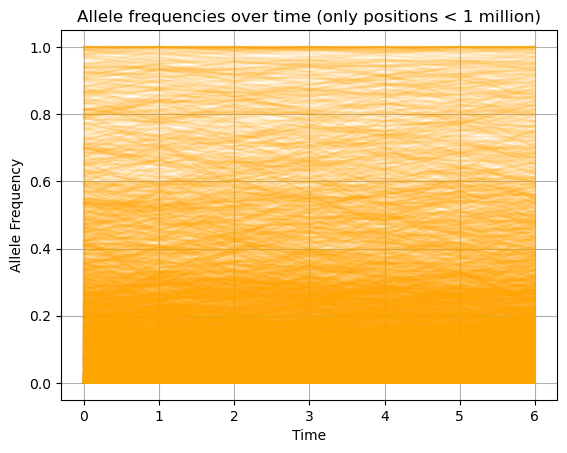

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Allele frequency over time, for every position below 1 million (trivial)
sns.lineplot(
    data=df[df.position < 1_000_000],
    x='time',
    y='allele_freq',
    hue='position',
    palette=['orange'],
    alpha=.1,
    legend=False
)
plt.title("Allele frequencies over time (only positions < 1 million)")
plt.xlabel("Time")
plt.ylabel("Allele Frequency")
plt.grid()
plt.show()

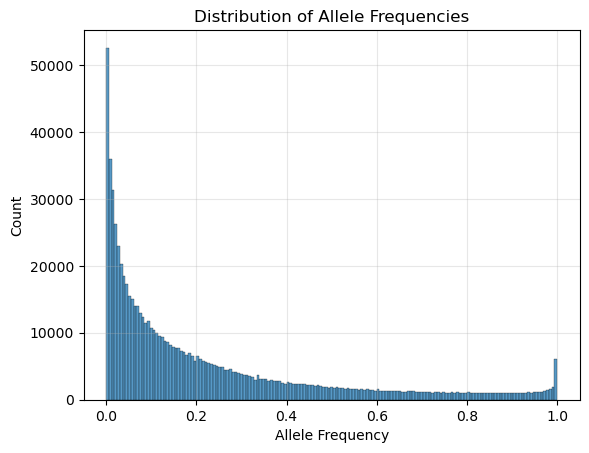

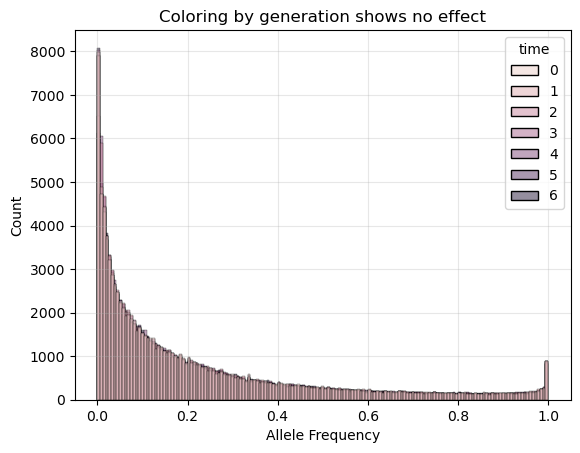

In [51]:
# Allele Frequency over time
sns.histplot(data=df, x='allele_freq')
plt.title("Distribution of Allele Frequencies")
plt.xlabel("Allele Frequency")
plt.grid(alpha=.3)
plt.show()

# Allele Frequency over time, colored by generation
# All generations seem to follow the same distribution
sns.histplot(data=df, x='allele_freq', hue='time')
plt.title("Coloring by generation shows no effect")
plt.xlabel("Allele Frequency")
plt.grid(alpha=.3)
plt.show()